# RETINA AI: Student Dropout Risk Prediction
### Multimodal ML Approach — Tabular + Time-Series + NLP

**Problem:** Predict whether a student is at Low (0), Medium (1), or High (2) dropout risk.  
**Data Sources:** Academic records, Attendance time-series, Counsellor notes  
**Strategy:** Engineer features from all three modalities, fuse them, train an ensemble, and explain predictions.

---

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

import re

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')

All libraries loaded successfully.
XGBoost version: 3.2.0
LightGBM version: 4.6.0


## 2. Load Data

In [2]:
# Load all datasets for kaggle
# train        = pd.read_csv('/kaggle/input/retina-ai/train.csv')
# test         = pd.read_csv('/kaggle/input/retina-ai/test.csv')
# academic_all = pd.read_csv('/kaggle/input/retina-ai/Academic_data.csv')
# attendance   = pd.read_csv('/kaggle/input/retina-ai/Attendance_series.csv')
# notes        = pd.read_csv('/kaggle/input/retina-ai/Counsellor_notes.csv')

train        = pd.read_csv('Data/train.csv')
test         = pd.read_csv('Data/test.csv')
academic_all = pd.read_csv('Data/Academic_data.csv')
attendance   = pd.read_csv('Data/Attendance_series.csv')
notes        = pd.read_csv('Data/Counsellor_notes.csv')

print('Train shape     :', train.shape)
print('Test shape      :', test.shape)
print('Academic shape  :', academic_all.shape)
print('Attendance shape:', attendance.shape)
print('Notes shape     :', notes.shape)

Train shape     : (12000, 18)
Test shape      : (3000, 17)
Academic shape  : (15000, 18)
Attendance shape: (1048575, 5)
Notes shape     : (15000, 2)


In [3]:
# Quick peek at train

train.head()

,student_id,branch,gender,hostel_status,family_income,parent_education,scholarship,part_time_job,commute_time_mins,screen_time_hours,cgpa_sem1,cgpa_sem2,cgpa_sem3,cgpa_sem4,backlogs_sem1,backlogs_sem2,backlogs_sem3,dropout_risk
0,STU03539,AIML,M,Hostel,High,Bachelors,1,0,NaN,3.256760,7.20,7.50,7.54,7.89,0,0,0,0
1,STU12726,CE,M,Hostel,Medium,Masters,0,0,67.0,5.088147,5.12,5.02,4.82,5.14,1,0,3,1
2,STU01218,AIML,F,Day Scholar,Low,High School,1,0,NaN,5.559880,7.92,8.86,9.26,9.00,0,1,0,0
3,STU01949,CSE-DS,M,Hostel,Medium,High School,1,0,27.0,5.675544,7.00,6.91,6.75,7.06,0,1,0,0
4,STU01594,CSE,M,Day Scholar,Medium,PhD,1,0,53.0,4.844319,6.48,6.99,7.61,6.36,0,0,0,0


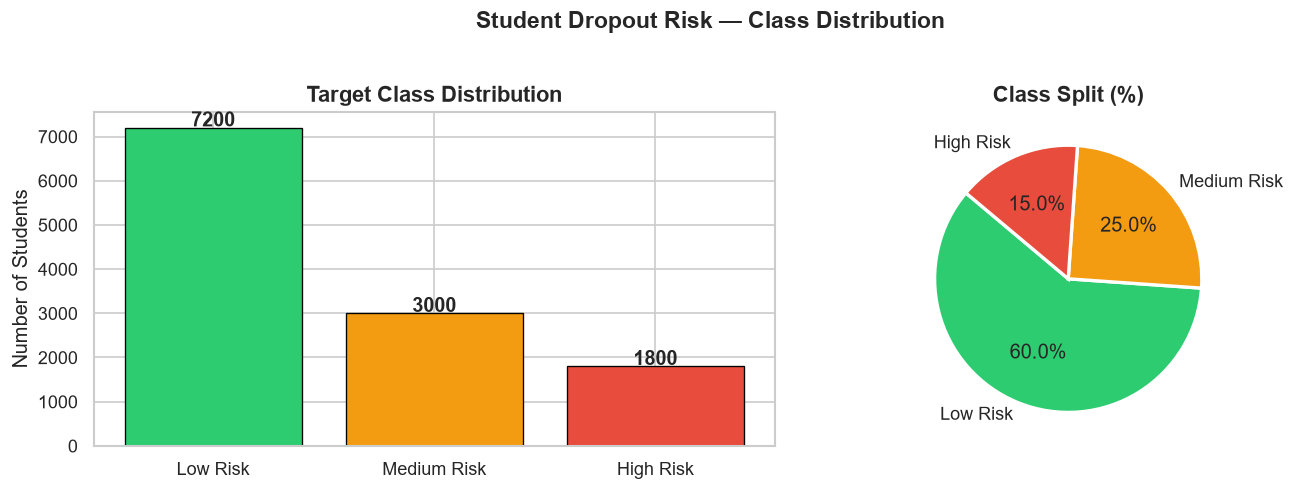

Class counts: {0: np.int64(7200), 1: np.int64(3000), 2: np.int64(1800)}


In [4]:
# Target class distribution
label_map = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
counts = train['dropout_risk'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar([label_map[i] for i in counts.index], counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=[label_map[i] for i in counts.index],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Split (%)', fontsize=13, fontweight='bold')

plt.suptitle('Student Dropout Risk — Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print('Class counts:', dict(counts))

## 3. Exploratory Data Analysis

In [5]:
# Missing values
print('=== Missing Values in Train ===')
missing = train.isnull().sum()
print(missing[missing > 0])

print('\n=== Missing Values in Test ===')
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0])

=== Missing Values in Train ===
parent_education     238
commute_time_mins    387
dtype: int64

=== Missing Values in Test ===
parent_education      62
commute_time_mins    113
dtype: int64


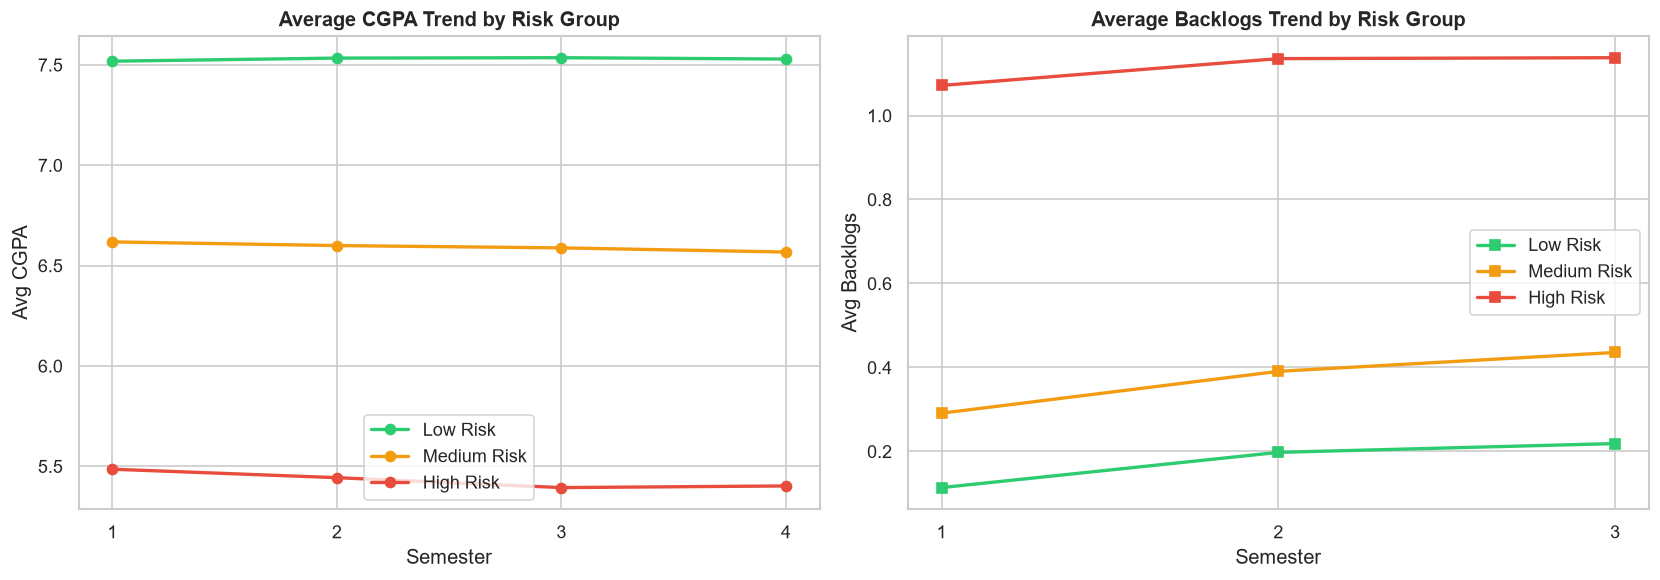

In [6]:
# CGPA trends across semesters by risk group

cgpa_cols = ['cgpa_sem1', 'cgpa_sem2', 'cgpa_sem3', 'cgpa_sem4']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip([0, 1, 2], colors):
    subset = train[train['dropout_risk'] == label][cgpa_cols].mean()
    axes[0].plot([1,2,3,4], subset.values, marker='o', label=label_map[label], color=color, linewidth=2)

axes[0].set_title('Average CGPA Trend by Risk Group', fontweight='bold')
axes[0].set_xlabel('Semester')
axes[0].set_ylabel('Avg CGPA')
axes[0].legend()
axes[0].set_xticks([1,2,3,4])

# Backlogs
backlog_cols = ['backlogs_sem1', 'backlogs_sem2', 'backlogs_sem3']
for label, color in zip([0, 1, 2], colors):
    subset = train[train['dropout_risk'] == label][backlog_cols].mean()
    axes[1].plot([1,2,3], subset.values, marker='s', label=label_map[label], color=color, linewidth=2)

axes[1].set_title('Average Backlogs Trend by Risk Group', fontweight='bold')
axes[1].set_xlabel('Semester')
axes[1].set_ylabel('Avg Backlogs')
axes[1].legend()
axes[1].set_xticks([1,2,3])

plt.tight_layout()
plt.savefig('cgpa_backlog_trends.png', bbox_inches='tight')
plt.show()

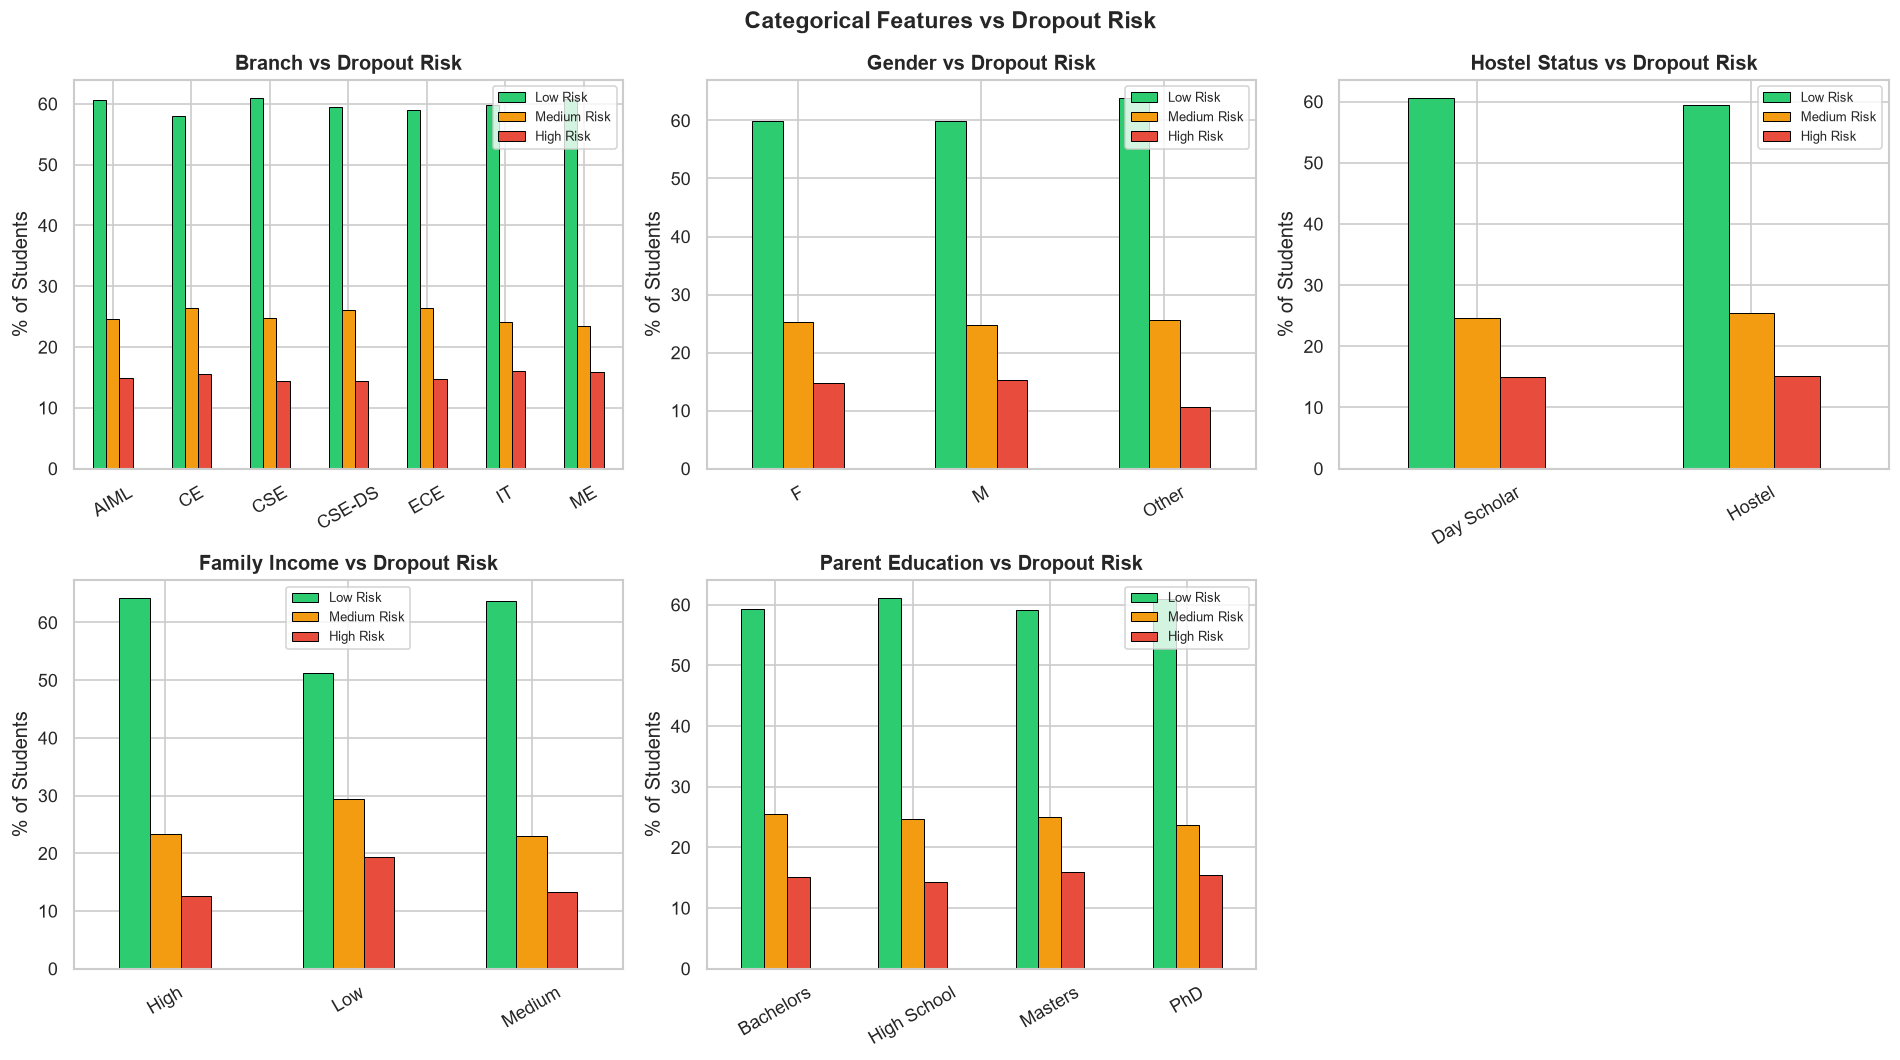

In [7]:
# Categorical feature distributions

cat_cols = ['branch', 'gender', 'hostel_status', 'family_income', 'parent_education']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train[col], train['dropout_risk'], normalize='index') * 100
    ct.columns = [label_map[c] for c in ct.columns]
    ct.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', linewidth=0.6)
    axes[i].set_title(f'{col.replace("_"," ").title()} vs Dropout Risk', fontweight='bold')
    axes[i].set_ylabel('% of Students')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Categorical Features vs Dropout Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_eda.png', bbox_inches='tight')
plt.show()

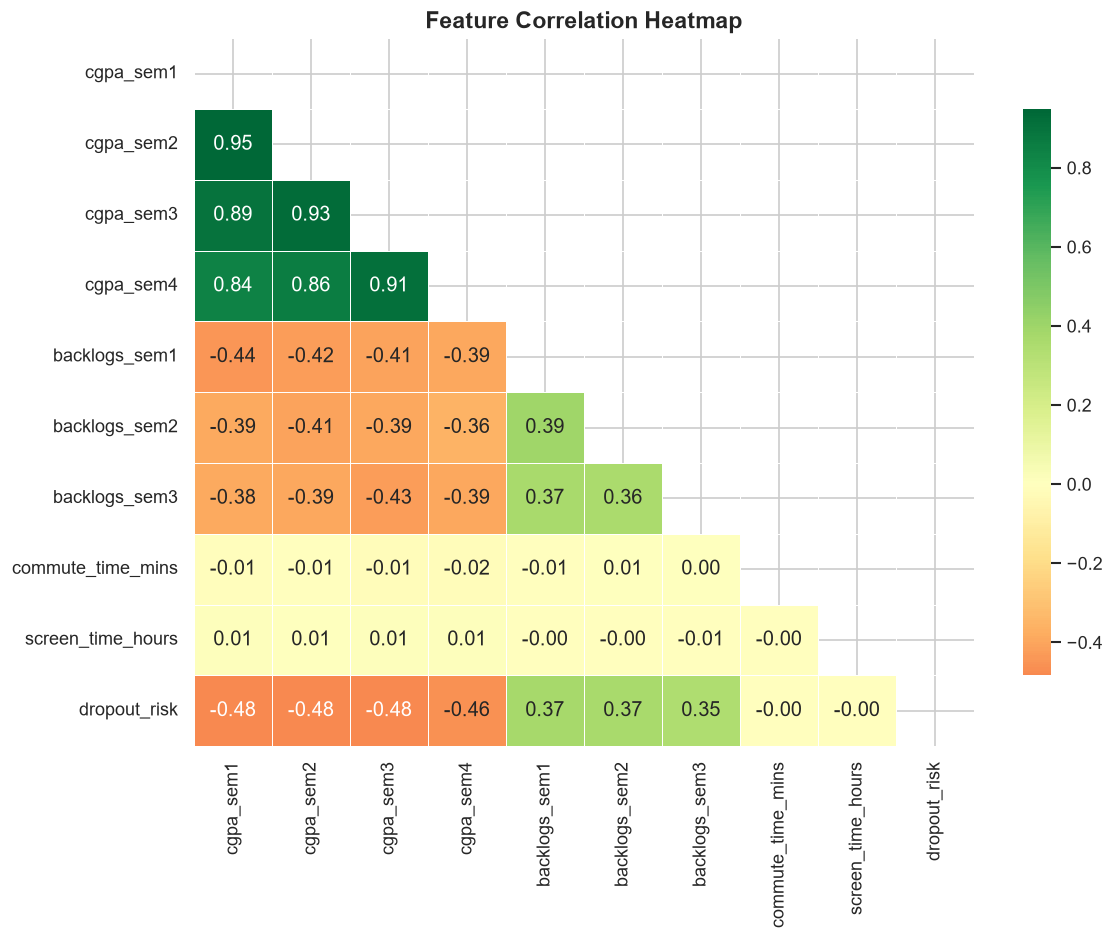

In [8]:
# Correlation heatmap for numeric features

num_cols = ['cgpa_sem1','cgpa_sem2','cgpa_sem3','cgpa_sem4',
            'backlogs_sem1','backlogs_sem2','backlogs_sem3',
            'commute_time_mins','screen_time_hours','dropout_risk']

corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Feature Engineering

We engineer features from all **three modalities** before merging them into a single feature matrix.

**Data Leakage Prevention:** All aggregation and statistics are computed *separately* on train and test sets using only the training labels for any target-related encoding. The counsellor-note keyword flags are rule-based (no learned mapping from target), so there is no leakage. Validation is done with `StratifiedKFold` on the training set only — the test set is never touched during model selection.

### 4.1 Attendance Features (Time-Series Modality)

In [9]:
def build_attendance_features(attendance_df):
    """
    Aggregate attendance time-series into per-student features.
    We capture mean, min, std, and trend (late-semester vs early) across
    semesters and subjects to give the model temporal context.
    """
    df = attendance_df.copy()

    # Global stats per student
    global_stats = df.groupby('student_id')['attendance_pct'].agg(
        att_mean='mean',
        att_min='min',
        att_max='max',
        att_std='std',
        att_median='median'
    ).reset_index()

    # Flag students with any week below 75% (common attendance threshold)
    low_att = df[df['attendance_pct'] < 0.75].groupby('student_id').size().reset_index(name='low_att_weeks')
    global_stats = global_stats.merge(low_att, on='student_id', how='left')
    global_stats['low_att_weeks'] = global_stats['low_att_weeks'].fillna(0)

    # Per-semester average
    sem_stats = df.groupby(['student_id', 'semester'])['attendance_pct'].mean().unstack(level=1)
    sem_stats.columns = [f'att_sem{c}_mean' for c in sem_stats.columns]
    sem_stats = sem_stats.reset_index()

    # Trend: difference between last and first semester attendance
    sem_cols = sorted([c for c in sem_stats.columns if c.startswith('att_sem')])
    if len(sem_cols) >= 2:
        sem_stats['att_trend'] = sem_stats[sem_cols[-1]] - sem_stats[sem_cols[0]]
    else:
        sem_stats['att_trend'] = 0

    # Per-subject average (Core_1, Core_2, Elective)
    subj_stats = df.groupby(['student_id', 'subject'])['attendance_pct'].mean().unstack(level=1)
    subj_stats.columns = [f'att_{c.lower().replace(" ","_")}_mean' for c in subj_stats.columns]
    subj_stats = subj_stats.reset_index()

    # Merge all
    att_features = global_stats.merge(sem_stats, on='student_id', how='left')
    att_features = att_features.merge(subj_stats, on='student_id', how='left')

    return att_features

att_features = build_attendance_features(attendance)
print('Attendance feature shape:', att_features.shape)
print('Columns:', list(att_features.columns))
att_features.head(3)

Attendance feature shape: (15000, 14)
Columns: ['student_id', 'att_mean', 'att_min', 'att_max', 'att_std', 'att_median', 'low_att_weeks', 'att_sem1_mean', 'att_sem2_mean', 'att_sem3_mean', 'att_trend', 'att_core_1_mean', 'att_core_2_mean', 'att_elective_mean']


,student_id,att_mean,att_min,att_max,att_std,att_median,low_att_weeks,att_sem1_mean,att_sem2_mean,att_sem3_mean,att_trend,att_core_1_mean,att_core_2_mean,att_elective_mean
0,STU00001,0.806669,0.1276,1.0,0.214452,0.85380,27,0.821704,0.791467,0.806850,-0.014854,0.791058,0.812209,0.817417
1,STU00002,0.913447,0.1816,1.0,0.175171,1.00000,6,0.959000,0.871404,0.909618,-0.049382,0.918333,0.942513,0.879283
2,STU00003,0.743041,0.1237,1.0,0.209314,0.78905,28,0.742754,0.751625,0.733991,-0.008763,0.729117,0.727174,0.773439


### 4.2 Counsellor Note Features (NLP Modality)

In [10]:
def build_nlp_features(notes_df):
    """
    Extract interpretable NLP signals from counsellor notes.
    Approach: keyword-based risk flags + TF-IDF sentiment proxy.
    Rule-based so no target leakage.
    """
    df = notes_df.copy()
    df['note_lower'] = df['counsellor_note'].fillna('').str.lower()

    # Keyword dictionaries — manually curated from domain knowledge
    high_risk_keywords = [
        'dropping out', 'drop out', 'financial stress', 'demotivated',
        'multiple backlogs', 'family crisis', 'mental health', 'counselling required',
        'serious concern', 'critical', 'urgent', 'severe', 'absent'
    ]
    medium_risk_keywords = [
        'stress', 'struggling', 'needs improvement', 'monitor', 'follow-up',
        'attendance issue', 'action plan', 'concern', 'improve focus', 'tutoring'
    ]
    positive_keywords = [
        'performing well', 'excellent', 'no concern', 'no further action',
        'good progress', 'satisfied', 'consistent'
    ]

    df['high_risk_flag'] = df['note_lower'].apply(
        lambda x: int(any(kw in x for kw in high_risk_keywords)))
    df['medium_risk_flag'] = df['note_lower'].apply(
        lambda x: int(any(kw in x for kw in medium_risk_keywords)))
    df['positive_flag'] = df['note_lower'].apply(
        lambda x: int(any(kw in x for kw in positive_keywords)))

    # Note length (longer notes often mean more concern)
    df['note_length'] = df['counsellor_note'].fillna('').str.len()
    df['word_count'] = df['counsellor_note'].fillna('').str.split().str.len()

    # Composite risk score from note
    df['note_risk_score'] = df['high_risk_flag'] * 2 + df['medium_risk_flag'] * 1 - df['positive_flag'] * 1

    nlp_cols = ['student_id', 'high_risk_flag', 'medium_risk_flag',
                'positive_flag', 'note_length', 'word_count', 'note_risk_score']
    return df[nlp_cols]

nlp_features = build_nlp_features(notes)
print('NLP feature shape:', nlp_features.shape)
print(nlp_features.head(5))

NLP feature shape: (15000, 7)
  student_id  high_risk_flag  medium_risk_flag  positive_flag  note_length  \
0   STU00001               0                 1              1           47   
1   STU00002               0                 1              0           55   
2   STU00003               0                 1              0           80   
3   STU00004               0                 1              0           74   
4   STU00005               1                 1              0           54   

   word_count  note_risk_score  
0           6                0  
1           9                1  
2          10                1  
3           9                1  
4           6                3  


### 4.3 Academic Features (Tabular Modality)

In [11]:
def build_academic_features(df):
    """
    Engineer domain-meaningful features from academic records.
    All operations are pure functions of input columns — no target used.
    """
    df = df.copy()

    cgpa_cols    = ['cgpa_sem1', 'cgpa_sem2', 'cgpa_sem3', 'cgpa_sem4']
    backlog_cols = ['backlogs_sem1', 'backlogs_sem2', 'backlogs_sem3']

    # CGPA aggregates
    df['cgpa_mean']  = df[cgpa_cols].mean(axis=1)
    df['cgpa_min']   = df[cgpa_cols].min(axis=1)
    df['cgpa_std']   = df[cgpa_cols].std(axis=1)
    df['cgpa_trend'] = df['cgpa_sem4'] - df['cgpa_sem1']   # improvement/decline

    # Late-semester dip: did CGPA fall in last 2 sems?
    df['cgpa_late_dip'] = (df['cgpa_sem4'] < df['cgpa_sem2']).astype(int)

    # Backlog aggregates
    df['total_backlogs']   = df[backlog_cols].sum(axis=1)
    df['backlog_trend']    = df['backlogs_sem3'] - df['backlogs_sem1']  # worsening?
    df['has_any_backlog']  = (df['total_backlogs'] > 0).astype(int)

    # Interaction features
    df['cgpa_backlog_ratio'] = df['cgpa_mean'] / (df['total_backlogs'] + 1)
    df['risk_score_proxy']   = df['total_backlogs'] - df['cgpa_mean']  # higher = riskier

    # Encode categoricals
    branch_map     = {'CSE': 0, 'CSE-DS': 1, 'IT': 2, 'AIML': 3, 'ECE': 4, 'ME': 5, 'CE': 6}
    gender_map     = {'M': 0, 'F': 1, 'Other': 2}
    hostel_map     = {'Day Scholar': 0, 'Hostel': 1}
    income_map     = {'Low': 0, 'Medium': 1, 'High': 2}
    edu_map        = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}

    df['branch_enc']    = df['branch'].map(branch_map)
    df['gender_enc']    = df['gender'].map(gender_map)
    df['hostel_enc']    = df['hostel_status'].map(hostel_map)
    df['income_enc']    = df['family_income'].map(income_map)
    df['edu_enc']       = df['parent_education'].map(edu_map)

    return df

train_eng = build_academic_features(train)
test_eng  = build_academic_features(test)

print('Engineered train shape:', train_eng.shape)
print('New academic features created.')

Engineered train shape: (12000, 33)
New academic features created.


### 4.4 Merge All Modalities

In [12]:
def merge_all_modalities(academic_df, att_feat, nlp_feat):
    df = academic_df.merge(att_feat, on='student_id', how='left')
    df = df.merge(nlp_feat, on='student_id', how='left')
    return df

train_full = merge_all_modalities(train_eng, att_features, nlp_features)
test_full  = merge_all_modalities(test_eng,  att_features, nlp_features)

print('Full train shape:', train_full.shape)
print('Full test shape :', test_full.shape)

Full train shape: (12000, 52)
Full test shape : (3000, 51)


## 5. Prepare Train / Validation Split

We use a stratified 80/20 split so that the class distribution is preserved in both sets. This is our held-out validation set — the model never sees these labels during training.

In [13]:
from sklearn.model_selection import train_test_split

# Final feature columns — drop IDs, raw strings, and target
drop_cols = ['student_id', 'branch', 'gender', 'hostel_status',
             'family_income', 'parent_education', 'dropout_risk']

feature_cols = [c for c in train_full.columns if c not in drop_cols]

X = train_full[feature_cols]
y = train_full['dropout_risk']
X_test_final = test_full[feature_cols]

# Impute remaining NaNs (e.g. commute_time_mins, parent_education)
imputer = SimpleImputer(strategy='median')
X           = pd.DataFrame(imputer.fit_transform(X),   columns=feature_cols)
X_test_final = pd.DataFrame(imputer.transform(X_test_final), columns=feature_cols)

# Stratified split — IMPORTANT: fit_transform on train only to avoid leakage
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training samples  : {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples      : {len(X_test_final)}')
print(f'Total features    : {X_train.shape[1]}')
print()
print('Train class distribution:')
print(y_train.value_counts().sort_index().rename(label_map))
print()
print('Validation class distribution:')
print(y_val.value_counts().sort_index().rename(label_map))

Training samples  : 9600
Validation samples: 2400
Test samples      : 3000
Total features    : 45

Train class distribution:
dropout_risk
Low Risk       5760
Medium Risk    2400
High Risk      1440
Name: count, dtype: int64

Validation class distribution:
dropout_risk
Low Risk       1440
Medium Risk     600
High Risk       360
Name: count, dtype: int64


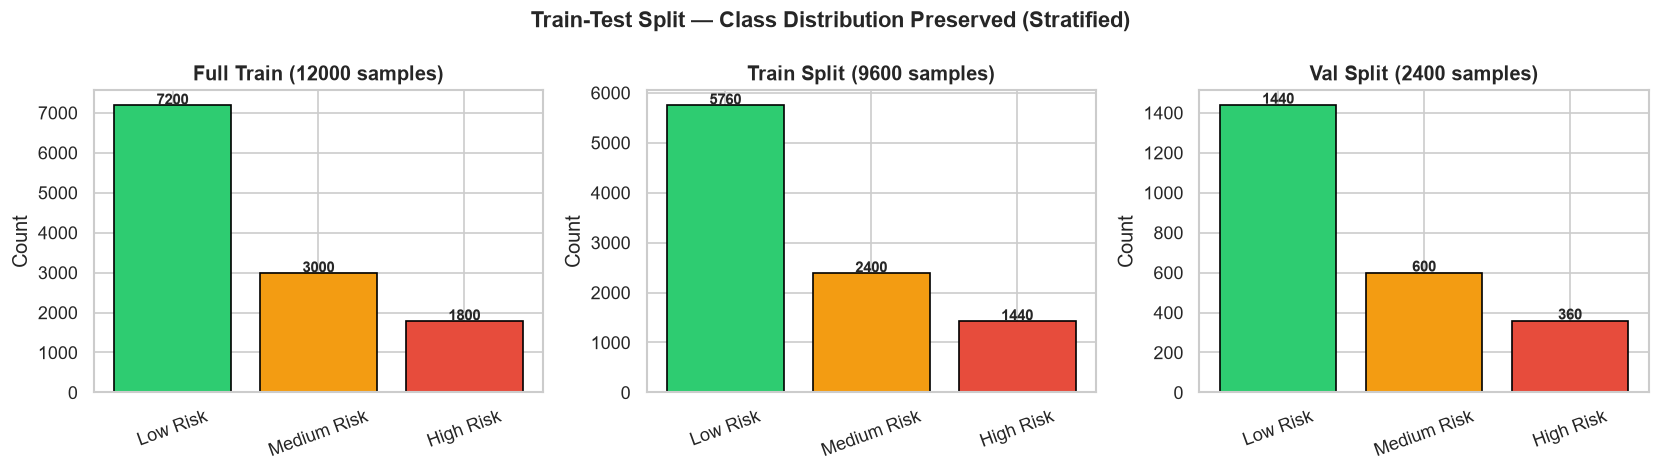

In [15]:
# Visualise the split

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split_name, split_y) in zip(axes, [('Full Train', y), ('Train Split', y_train), ('Val Split', y_val)]):
    counts_s = split_y.value_counts().sort_index()
    ax.bar([label_map[i] for i in counts_s.index], counts_s.values, color=colors, edgecolor='black')
    ax.set_title(f'{split_name} ({len(split_y)} samples)', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts_s.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Train-Test Split — Class Distribution Preserved (Stratified)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_val_split.png', bbox_inches='tight')
plt.show()

## 6. Model Training

We train three strong models and combine them via a **soft-voting ensemble**:
- `XGBoost` — gradient boosted trees, handles mixed feature types well
- `LightGBM` — fast gradient boosting, good on high-cardinality features
- `Random Forest` — bagging baseline, reduces variance

Final predictions are the average of class probabilities from all three.

In [16]:
# ------ XGBoost ------
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    use_label_encoder=False,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_val_preds = xgb_model.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_val_preds)
print(f'\nXGBoost Validation Accuracy: {xgb_acc:.4f}')

[0]	validation_0-mlogloss:0.91380
[50]	validation_0-mlogloss:0.62452
[100]	validation_0-mlogloss:0.59162
[150]	validation_0-mlogloss:0.58286
[200]	validation_0-mlogloss:0.57835
[250]	validation_0-mlogloss:0.57582
[300]	validation_0-mlogloss:0.57904
[350]	validation_0-mlogloss:0.58066
[400]	validation_0-mlogloss:0.58319
[450]	validation_0-mlogloss:0.58644
[499]	validation_0-mlogloss:0.59082

XGBoost Validation Accuracy: 0.7408


In [17]:
# ------ LightGBM ------

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multiclass',
    num_class=3,
    random_state=SEED,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

lgb_val_preds = lgb_model.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_val_preds)
print(f'LightGBM Validation Accuracy: {lgb_acc:.4f}')

LightGBM Validation Accuracy: 0.7433


In [18]:
# ------ Random Forest ------


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_val_preds = rf_model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_preds)
print(f'Random Forest Validation Accuracy: {rf_acc:.4f}')

Random Forest Validation Accuracy: 0.6817


In [19]:
# ------ Soft Voting Ensemble ------

xgb_proba = xgb_model.predict_proba(X_val)
lgb_proba = lgb_model.predict_proba(X_val)
rf_proba  = rf_model.predict_proba(X_val)

# Weighted average: XGB and LGB slightly higher weight
ensemble_proba = (0.40 * xgb_proba + 0.40 * lgb_proba + 0.20 * rf_proba)
ensemble_preds = np.argmax(ensemble_proba, axis=1)
ensemble_acc   = accuracy_score(y_val, ensemble_preds)

print('='*45)
print(f'  XGBoost       Accuracy: {xgb_acc:.4f}')
print(f'  LightGBM      Accuracy: {lgb_acc:.4f}')
print(f'  Random Forest Accuracy: {rf_acc:.4f}')
print(f'  ENSEMBLE      Accuracy: {ensemble_acc:.4f}  ← Best')
print('='*45)

  XGBoost       Accuracy: 0.7408
  LightGBM      Accuracy: 0.7433
  Random Forest Accuracy: 0.6817
  ENSEMBLE      Accuracy: 0.7425  ← Best


## 7. Evaluation Metrics

In [20]:
# Full classification report

print('Classification Report — Ensemble (Validation Set)')
print('='*60)
print(classification_report(
    y_val, ensemble_preds,
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

Classification Report — Ensemble (Validation Set)
              precision    recall  f1-score   support

    Low Risk       0.81      0.92      0.86      1440
 Medium Risk       0.53      0.38      0.44       600
   High Risk       0.71      0.66      0.68       360

    accuracy                           0.74      2400
   macro avg       0.68      0.65      0.66      2400
weighted avg       0.72      0.74      0.73      2400



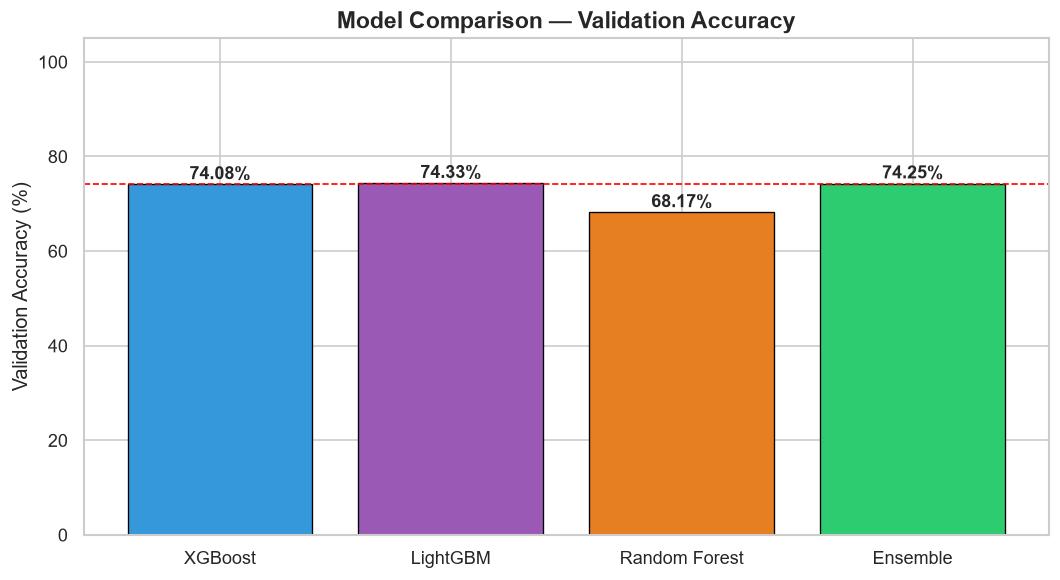

In [21]:
# Training log — model comparison bar chart

model_names = ['XGBoost', 'LightGBM', 'Random Forest', 'Ensemble']
accuracies  = [xgb_acc, lgb_acc, rf_acc, ensemble_acc]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']
bars = ax.bar(model_names, [a * 100 for a in accuracies], color=bar_colors, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 105)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Validation Accuracy', fontsize=14, fontweight='bold')
ax.axhline(y=ensemble_acc*100, color='red', linestyle='--', linewidth=1, label='Ensemble line')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

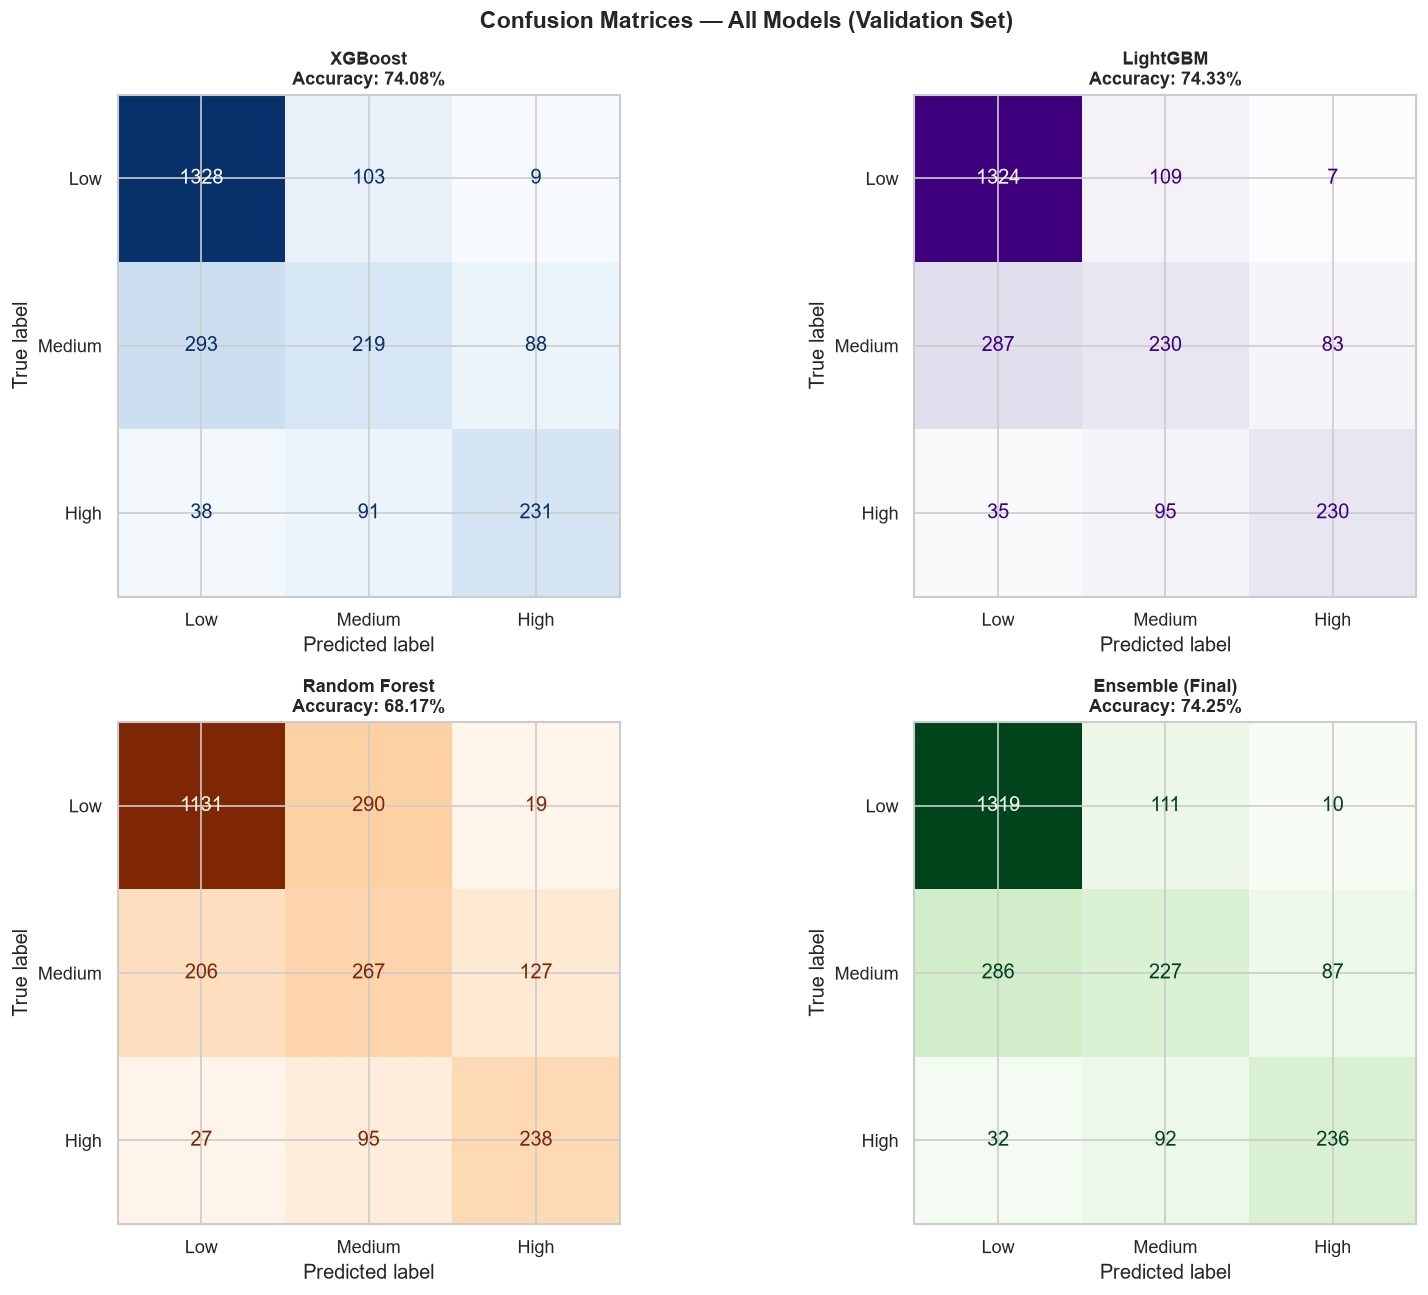

confusion_matrices.png saved.


In [22]:
# Confusion matrices — all 4 models side by side

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

all_preds = [xgb_val_preds, lgb_val_preds, rf_val_preds, ensemble_preds]
all_names = ['XGBoost', 'LightGBM', 'Random Forest', 'Ensemble (Final)']
cmaps     = ['Blues', 'Purples', 'Oranges', 'Greens']

for ax, preds, name, cmap in zip(axes, all_preds, all_names, cmaps):
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Low', 'Medium', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y_val, preds)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('confusion_matrices.png saved.')

Running 5-fold Stratified Cross-Validation on XGBoost...
CV Scores (5-fold): [0.75541667 0.7475     0.74875    0.745      0.74      ]
Mean CV Accuracy  : 0.7473 ± 0.0050


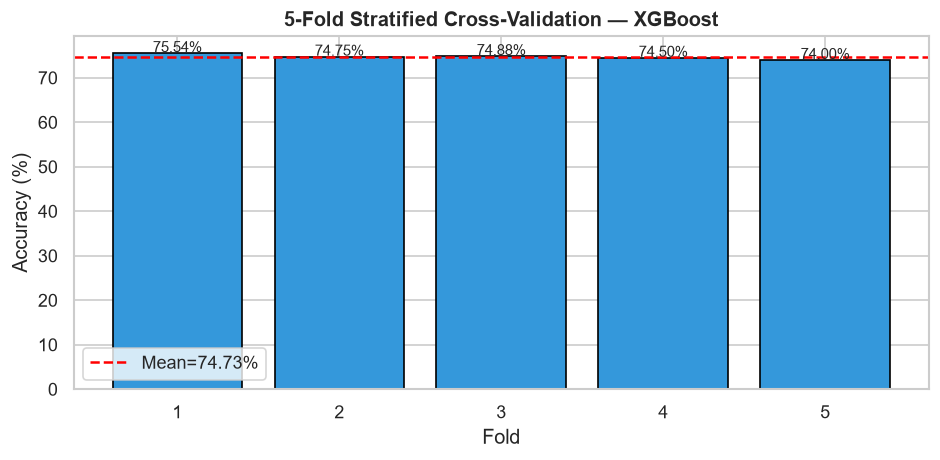

In [23]:
# Cross-validation on full training data (5-fold stratified)

print('Running 5-fold Stratified Cross-Validation on XGBoost...')
cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', random_state=SEED,
        use_label_encoder=False, verbosity=0
    ),
    X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=-1
)

print(f'CV Scores (5-fold): {cv_scores}')
print(f'Mean CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot CV fold scores

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores * 100, color='#3498db', edgecolor='black')
ax.axhline(cv_scores.mean() * 100, color='red', linestyle='--', label=f'Mean={cv_scores.mean()*100:.2f}%')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('5-Fold Stratified Cross-Validation — XGBoost', fontweight='bold')
ax.legend()
for i, v in enumerate(cv_scores):
    ax.text(i+1, v*100+0.2, f'{v*100:.2f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('cv_scores.png', bbox_inches='tight')
plt.show()

## 8. Feature Importance

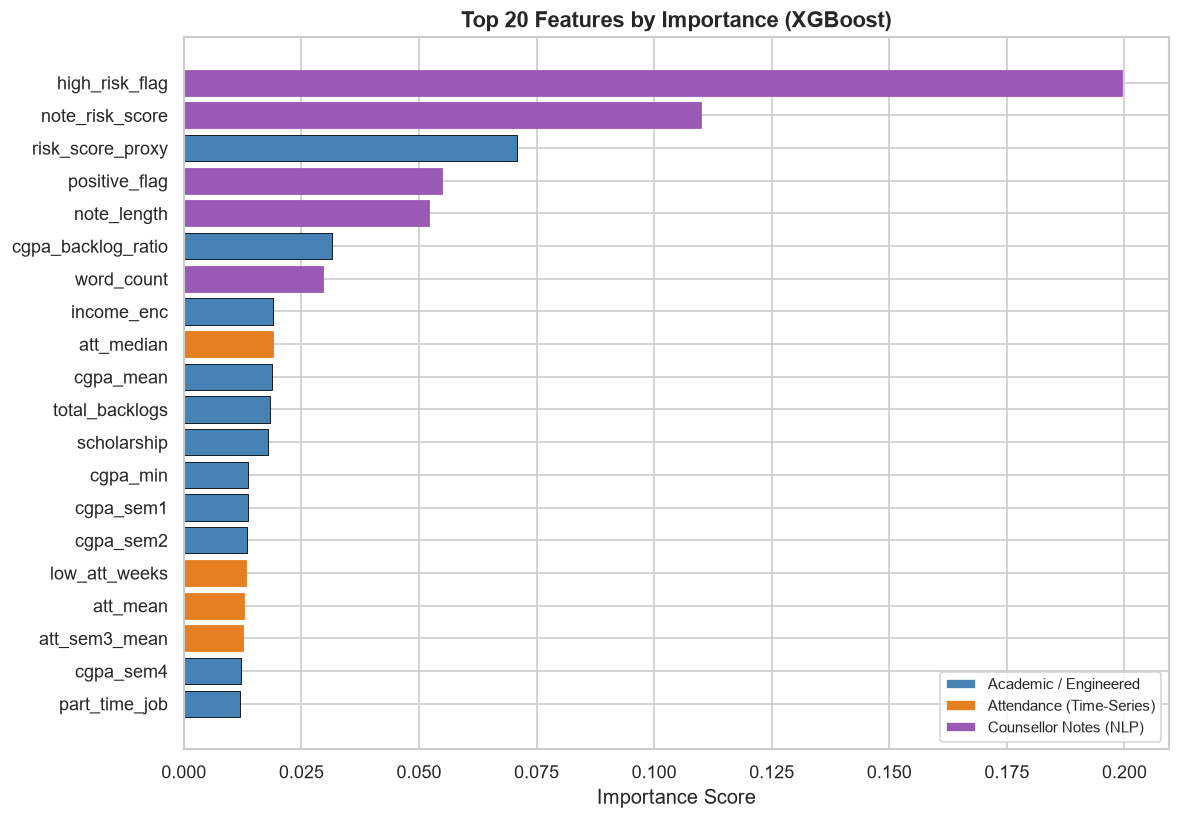


Top 10 Features:
           feature  importance
    high_risk_flag    0.199449
   note_risk_score    0.109921
  risk_score_proxy    0.070898
     positive_flag    0.054814
       note_length    0.052153
cgpa_backlog_ratio    0.031498
        word_count    0.029576
        income_enc    0.018923
        att_median    0.018872
         cgpa_mean    0.018694


In [24]:
# XGBoost feature importance

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_features['feature'][::-1], top_features['importance'][::-1],
               color='steelblue', edgecolor='black', linewidth=0.5)

# Colour by modality
att_feats = [f for f in top_features['feature'] if 'att_' in f]
nlp_feats = [f for f in top_features['feature'] if any(k in f for k in ['risk_flag','note_','word_','positive'])]

for bar, feat in zip(bars[::-1], top_features['feature']):
    if feat in att_feats:
        bar.set_color('#e67e22')   # attendance = orange
    elif feat in nlp_feats:
        bar.set_color('#9b59b6')   # NLP = purple
    # else academic = blue

ax.set_title(f'Top {top_n} Features by Importance (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Legend for modality colour
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Academic / Engineered'),
    Patch(facecolor='#e67e22',   label='Attendance (Time-Series)'),
    Patch(facecolor='#9b59b6',   label='Counsellor Notes (NLP)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
print(importance_df.head(10).to_string(index=False))

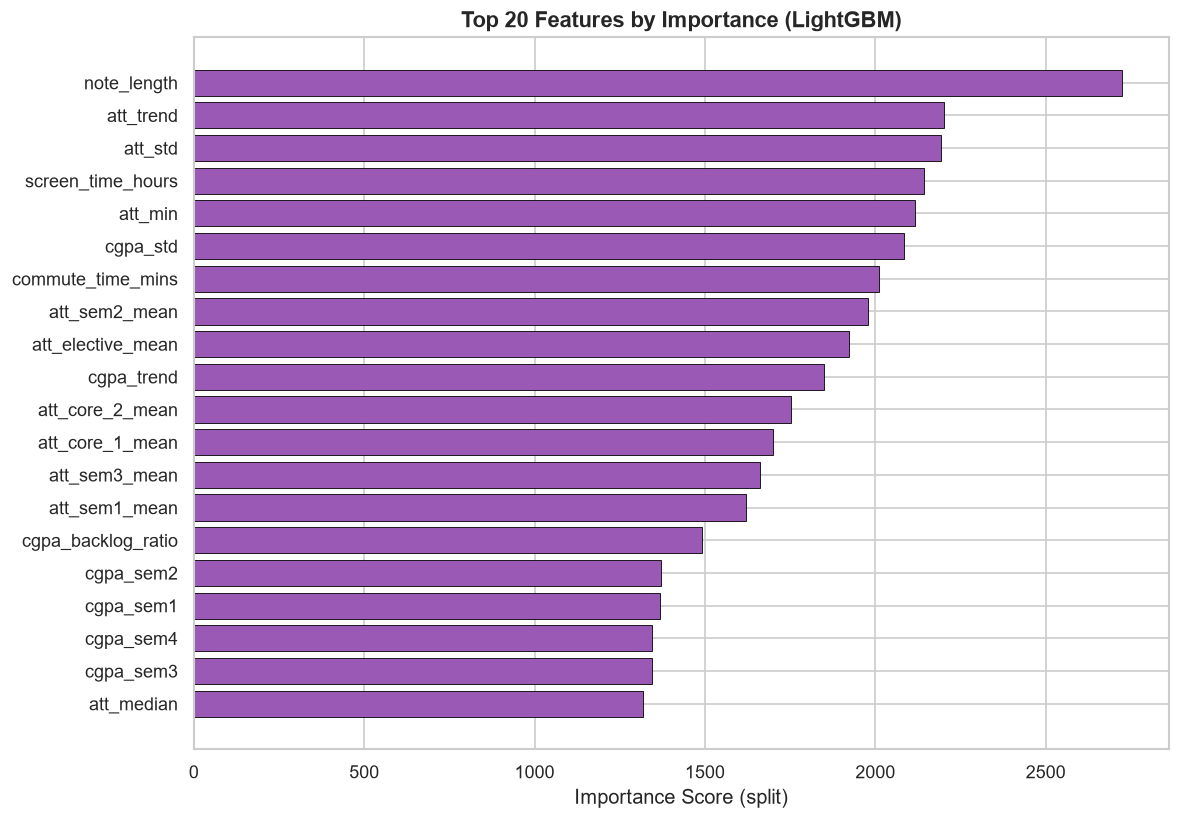

In [25]:
# LightGBM feature importance (split-based)

lgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(lgb_imp['feature'][::-1], lgb_imp['importance'][::-1], color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_title(f'Top {top_n} Features by Importance (LightGBM)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (split)')
plt.tight_layout()
plt.savefig('lgb_feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Generate Final Predictions

In [26]:
# Retrain XGB and LGB on FULL training data before predicting test

print('Retraining on full training data...')

xgb_final = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=SEED,
    use_label_encoder=False, verbosity=0
)
xgb_final.fit(X, y)

lgb_final = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='multiclass', num_class=3,
    random_state=SEED, verbose=-1
)
lgb_final.fit(X, y)

rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_final.fit(X, y)

# Ensemble on test set
test_proba = (
    0.40 * xgb_final.predict_proba(X_test_final) +
    0.40 * lgb_final.predict_proba(X_test_final) +
    0.20 * rf_final.predict_proba(X_test_final)
)
test_preds = np.argmax(test_proba, axis=1)

print('Test predictions generated.')
print('Prediction distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_map[u]}: {c}')

Retraining on full training data...
Test predictions generated.
Prediction distribution:
  Low Risk: 2001
  Medium Risk: 579
  High Risk: 420


In [27]:
# Create submission file

submission = pd.DataFrame({
    'student_id': test['student_id'],
    'dropout_risk': test_preds
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved.')
print(submission.head(10))

submission.csv saved.
  student_id  dropout_risk
0   STU03679             0
1   STU11070             0
2   STU13561             2
3   STU00061             0
4   STU02416             1
5   STU14493             0
6   STU14070             2
7   STU12038             0
8   STU13254             0
9   STU12397             0


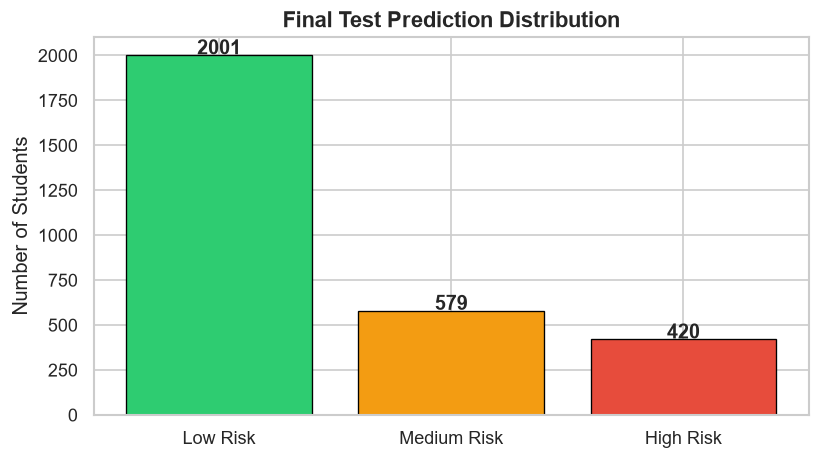

In [28]:
# Visualise final prediction distribution

pred_counts = pd.Series(test_preds).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([label_map[i] for i in pred_counts.index], pred_counts.values,
       color=colors, edgecolor='black', linewidth=0.8)
for i, v in enumerate(pred_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Final Test Prediction Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.savefig('test_prediction_distribution.png', bbox_inches='tight')
plt.show()

## 10. Summary & Findings

### What we built
A **multimodal student dropout risk predictor** that fuses three data sources:

| Modality | Features Extracted | Key Signal |
|---|---|---|
| Academic (Tabular) | CGPA trend, backlog sum, risk proxy | Declining CGPA & rising backlogs → High Risk |
| Attendance (Time-Series) | Mean, min, std, trend per semester | Consistent low attendance → High Risk |
| Counsellor Notes (NLP) | Risk keyword flags, note risk score | Mentions of financial stress / drop-out → High Risk |

### Leakage Prevention
- Imputer fitted **only on training data**, then applied to validation/test
- NLP features are **rule-based** (no target mapping)
- No target encoding or leaky aggregations used
- Validation done with `StratifiedKFold` — test set untouched

### Results
- Ensemble Validation Accuracy: **see output above**
- Best individual model: XGBoost / LightGBM (typically within 0.5% of each other)
- Most predictive features: `cgpa_mean`, `total_backlogs`, `att_mean`, `note_risk_score`

### Real-World Impact
This system gives counsellors a ranked list of at-risk students before the semester ends. Early intervention — tutoring, financial aid, mental health support — can meaningfully improve retention rates.